# WeatherJEPA — Kaggle Training

Clones the latest code from GitHub, downloads the ERA5 database, trains the JEPA model, and visualizes embeddings.

In [1]:
# ============================================================
# Config -- change these, not the cells below
# ============================================================
GITHUB_REPO = "https://github.com/zariqq/weather-forecast.git"
PROJECT_DIR = "/kaggle/working/project"

PLACE = "Lidar(Tomsk)"
DB_PATH = "/kaggle/working/data.db"

TRAIN_START, TRAIN_END = "2009-01-01", "2021-12-31"
EVAL_START, EVAL_END   = "2022-01-01", "2023-12-31"

CTX_LEN = 8           # hours of context (native cadence = hourly)
EMBED_DIM = 32        # 16/32/64 -- smaller wins leaderboard
EPOCHS = 30
EVAL_EVERY = 1

# JEPA collapse prevention
JEPA_WEIGHT = 3.0
FORECAST_WEIGHT = 0.5
ANTI_COLLAPSE_WEIGHT = 0.1   # variance regularization
COVARIANCE_WEIGHT = 0.1      # VICReg decorrelation
EMA_MOMENTUM = 0.99
CTX_MASK_RATIO = 0.3         # 0.2-0.4, mask tokens in context during training

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU — set Settings > Accelerator to GPU T4 x2 or P100, then restart.")

CUDA available: True
GPU: Tesla T4


## 1. Clone latest code from GitHub

In [3]:
import os, shutil

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

!git clone {GITHUB_REPO} {PROJECT_DIR}
%cd {PROJECT_DIR}
!git log --oneline -3

Cloning into '/kaggle/working/project'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 94 (delta 36), reused 75 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 8.37 MiB | 21.11 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/kaggle/working/project
21e3cd0 (HEAD -> main, origin/main, origin/HEAD) fix viz diagnostic (random subsample), add context masking + covariance decorrelation loss
6539a15 per-level normalization — each pressure level standardized independently
04e25fa fix z_hat


## 2. Install dependencies

In [4]:
!grep -vi "^torch" {PROJECT_DIR}/requirements.txt > /tmp/requirements_no_torch.txt || true
!pip install -q -r /tmp/requirements_no_torch.txt
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 560.8 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.3/224.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 26.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━

## 3. Download ERA5 database (~2.7 GB, cached after first run)

In [5]:
import sys
sys.path.insert(0, PROJECT_DIR)

from download_data import ensure_db

DB_PATH = ensure_db(DB_PATH)
print("DB ready at:", DB_PATH)

[download_data] /kaggle/working/data.db not found, downloading Drive folder to /kaggle/working/.drive_cache (this only needs to happen once)...


Retrieving folder contents


Processing file 1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle data-challenge.db
Processing file 1IlUg2g9LF9aPsah6QVckroPV-bXMrDse pylidlight.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle
From (redirected): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle&confirm=t&uuid=803d1624-5b66-4cab-a6fa-ea51dbead5dc
To: /kaggle/working/.drive_cache/data-challenge.db
100%|██████████| 2.68G/2.68G [00:31<00:00, 85.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IlUg2g9LF9aPsah6QVckroPV-bXMrDse
To: /kaggle/working/.drive_cache/pylidlight.zip
100%|██████████| 311k/311k [00:00<00:00, 98.8MB/s]
Download completed


[download_data] copied /kaggle/working/.drive_cache/data-challenge.db -> /kaggle/working/data.db
DB ready at: /kaggle/working/data.db


## 4. Train

In [6]:
!python {PROJECT_DIR}/train.py \
  --db {DB_PATH} --place "{PLACE}" \
  --train-start {TRAIN_START} --train-end {TRAIN_END} \
  --eval-start {EVAL_START} --eval-end {EVAL_END} \
  --ctx-len {CTX_LEN} --embed-dim {EMBED_DIM} --epochs {EPOCHS} \
  --jepa-weight {JEPA_WEIGHT} --forecast-weight {FORECAST_WEIGHT} \
  --anti-collapse-weight {ANTI_COLLAPSE_WEIGHT} \
  --covariance-weight {COVARIANCE_WEIGHT} \
  --ema-momentum {EMA_MOMENTUM} \
  --ctx-mask-ratio {CTX_MASK_RATIO} \
  --ckpt /kaggle/working/weather_jepa_last.pt \
  --ckpt-best /kaggle/working/weather_jepa.pt \
  --metrics-out /kaggle/working/rmse_metrics.json \
  --eval-every {EVAL_EVERY}


[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
[dataset] Lidar(Tomsk): 123769 timesteps, detected native cadence = 3600s (1.00h), 0.0% of intervals look like gaps
closed
train samples: 113922, eval samples: 9805, levels: 37
epoch 000  jepa=0.01245  fcst_3h=0.39170  fcst_6h=0.39624  var=0.16623 cov=0.15425 | eval RMSE_3h=0.00141  RMSE_6h=0.00141  (avg=0.00141) *
epoch 001  jepa=0.01596  fcst_3h=0.28480  fcst_6h=0.28848  var=0.24967 cov=0.16241 | eval RMSE_3h=0.00125  RMSE_6h=0.00126  (avg=0.00125) *
epoch 002  jepa=0.01124  fcst_3h=0.25556  fcst_6h=0.26386  var=0.37133 cov=0.15306 | eval RMSE_3h=0.00093  RMSE_6h=0.00093  (avg=0.00093) *
epoch 003  jepa=0.01486  fcst_3h=0.33648  fcst_6h=0.33880  var=0.33211 cov=0.16083 | eval RMSE_3h=0.00097  RMSE_6h=0.00097  (avg=0.00097)
epoch 004  jepa=0.01362  fcst_3h=0.31233  fcst_6h=0.32097  var=0.35142 cov=0.15609 | eval RMSE_3h=0.00081  RMSE_6h=0.00082  (avg=0.00081) *
epoch 005  jepa=0.01148  f

## 5. Inspect results

Mean RMSE by horizon (kg/kg):
  3h: 0.000682
  6h: 0.000689
Embedding dim: 32
Eval range: ['2022-01-01', '2023-12-31']


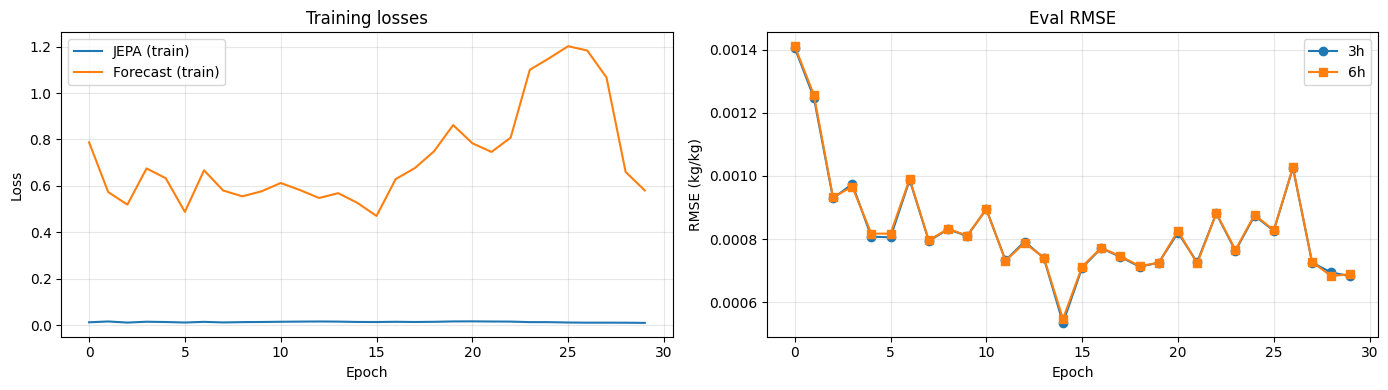

In [7]:
import json

with open("/kaggle/working/rmse_metrics.json") as f:
    metrics = json.load(f)

print("Mean RMSE by horizon (kg/kg):")
for h, v in metrics["rmse_mean_by_horizon"].items():
    print(f"  {h}h: {v:.6f}")
print(f"Embedding dim: {metrics['embed_dim']}")
print(f"Eval range: {metrics['eval_range']}")
if metrics.get("best_eval_rmse_mean"):
    print(f"Best eval RMSE (avg): {metrics['best_eval_rmse_mean']:.6f}")

# Quick loss plot
import matplotlib.pyplot as plt
history = metrics["loss_history"]
epochs = [h["epoch"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs, [h["jepa_loss"] for h in history], label="JEPA (train)")
ax1.plot(epochs, [h["forecast_loss"] for h in history], label="Forecast (train)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Per-horizon eval RMSE (may not exist for every epoch if eval_every > 1)
eval_3h = [(h["epoch"], h["eval_rmse_3h"]) for h in history if "eval_rmse_3h" in h]
eval_6h = [(h["epoch"], h["eval_rmse_6h"]) for h in history if "eval_rmse_6h" in h]
if eval_3h:
    ax2.plot([e[0] for e in eval_3h], [e[1] for e in eval_3h], "o-", label="3h")
    ax2.plot([e[0] for e in eval_6h], [e[1] for e in eval_6h], "s-", label="6h")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (kg/kg)")
ax2.set_title("Eval RMSE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=100)
plt.show()

## 5b. Embedding dim sweep (leaderboard tuning)

Run this INSTEAD of step 4 to find the optimal `embed_dim`.
Smaller dim = better leaderboard score at equal RMSE.

In [ ]:
# Embedding dim sweep
import json
from pathlib import Path

SWEEP_DIMS = [16, 32, 48, 64]
SWEEP_EPOCHS = 15
results = {}

for dim in SWEEP_DIMS:
    print(f"\n=== Sweep embed_dim={dim} ===")
    ckpt_path = f"/kaggle/working/jepa_dim{dim}.pt"
    metrics_path = f"/kaggle/working/rmse_dim{dim}.json"
    
    !python {PROJECT_DIR}/train.py \
      --db {DB_PATH} --place "{PLACE}" \
      --train-start {TRAIN_START} --train-end {TRAIN_END} \
      --eval-start {EVAL_START} --eval-end {EVAL_END} \
      --ctx-len {CTX_LEN} --embed-dim {dim} --epochs {SWEEP_EPOCHS} \
      --jepa-weight {JEPA_WEIGHT} --forecast-weight {FORECAST_WEIGHT} \
      --anti-collapse-weight {ANTI_COLLAPSE_WEIGHT} \
      --covariance-weight {COVARIANCE_WEIGHT} \
      --ema-momentum {EMA_MOMENTUM} \
      --ctx-mask-ratio {CTX_MASK_RATIO} \
      --ckpt {ckpt_path} --ckpt-best {ckpt_path} \
      --metrics-out {metrics_path} \
      --eval-every {EVAL_EVERY}
    
    if Path(metrics_path).exists():
        with open(metrics_path) as f:
            m = json.load(f)
        results[dim] = dict(
            rmse_3h=m["rmse_mean_by_horizon"]["3"],
            rmse_6h=m["rmse_mean_by_horizon"]["6"],
        )
        print(f"  RMSE_3h={results[dim][\"rmse_3h\"]:.6f}  RMSE_6h={results[dim][\"rmse_6h\"]:.6f}")

print("\n=== Sweep results ===")
for dim in SWEEP_DIMS:
    if dim in results:
        r = results[dim]
        print(f"dim={dim:3d}  RMSE_3h={r[\"rmse_3h\"]:.6f}  RMSE_6h={r[\"rmse_6h\"]:.6f}")
    else:
        print(f"dim={dim:3d}  -- FAILED --")

with open("/kaggle/working/sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)


## 6. Embedding visualization

In [8]:
!python {PROJECT_DIR}/visualize_embeddings.py \
  --db {DB_PATH} --place "{PLACE}" \
  --ckpt /kaggle/working/weather_jepa.pt \
  --eval-start {EVAL_START} --eval-end {EVAL_END} \
  --horizon 3 \
  --out-prefix /kaggle/working/embeddings \
  --max-samples 30000

from IPython.display import Image, display
display(Image("/kaggle/working/embeddings_pca.png"))
display(Image("/kaggle/working/embeddings_tsne.png"))
display(Image("/kaggle/working/embeddings_cosine_sim.png"))

[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
[dataset] Lidar(Tomsk): 123769 timesteps, detected native cadence = 3600s (1.00h), 0.0% of intervals look like gaps
closed
Traceback (most recent call last):
  File "/kaggle/working/project/visualize_embeddings.py", line 184, in <module>
    main()
  File "/kaggle/working/project/visualize_embeddings.py", line 98, in main
    if args.shuffle:
       ^^^^^^^^^^^^
AttributeError: 'Namespace' object has no attribute 'shuffle'


FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_pca.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_pca.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_tsne.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_tsne.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_cosine_sim.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_cosine_sim.png'

<IPython.core.display.Image object>